In [ ]:
# === Dependency Installation ===
!pip install gensim scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

from IPython.display import display


Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/SKRIPSI/dataset_preprocessed.csv"
df = pd.read_csv(DATA_PATH)

print("Jumlah data:", len(df))
display(df.head(3))


Jumlah data: 150466


,processed_text,tokens,label
0,ponsel huawei honor c dibanderol rp juta jakar...,"['ponsel', 'huawei', 'honor', 'c', 'dibanderol...",6
1,asosiasi rpp e commerce sesuai hasil diskusi j...,"['asosiasi', 'rpp', 'e', 'commerce', 'sesuai',...",6
2,pemesan iphone jadi sabun karyawan pesaing laz...,"['pemesan', 'iphone', 'jadi', 'sabun', 'karyaw...",6


In [ ]:
sentences = [text.split() for text in df["processed_text"]]

print("Jumlah dokumen untuk Word2Vec:", len(sentences))
print("Contoh input Word2Vec (3 data):")
for i in range(3):
    print(sentences[i])


Jumlah dokumen untuk Word2Vec: 150466
Contoh input Word2Vec (3 data):
['ponsel', 'huawei', 'honor', 'c', 'dibanderol', 'rp', 'juta', 'jakarta', 'kompas', 'com', 'ponsel', 'android', 'huawei', 'honor', 'c', 'resmi', 'meluncur', 'pasar', 'indonesia', 'rabu', 'perusahaan', 'asal', 'tiongkok', 'merancangnya', 'ponsel', 'kelas', 'menengah', 'banderol', 'harga', 'rp', 'juta', 'merancangnya', 'pengguna', 'usia', 'tahun', 'ponsel', 'menggunakan', 'prosesor', 'octa', 'core', 'kinerja', 'jadi', 'lebih', 'mulus', 'bermain', 'game', 'tidak', 'lag', 'klaim', 'sales', 'manager', 'device', 'department', 'huawei', 'indonesia', 'darren', 'sela', 'peluncuran', 'ponsel', 'tersebut', 'jakarta', 'ponsel', 'berukuran', 'inci', 'menggunakan', 'prosesor', 'kirin', 'berkecepatan', 'ghz', 'pembuatanya', 'hisilicon', 'sebuah', 'perusahaan', 'semi', 'konduktor', 'milik', 'huawei', 'honor', 'c', 'dibekali', 'memori', 'ram', 'gb', 'rom', 'gb', 'media', 'penyimpanan', 'aplikasi', 'honor', 'c', 'menggunakan', 'sistem

In [ ]:
EMBEDDING_DIM = 100

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    epochs=10
)


In [ ]:
print("Jumlah kosakata Word2Vec:", len(w2v_model.wv))


Jumlah kosakata Word2Vec: 71000


In [ ]:
sample_words = list(w2v_model.wv.index_to_key[:3])

print("Contoh representasi vektor kata:")
for word in sample_words:
    print(f"\nKata: {word}")
    print(w2v_model.wv[word][:10])  # tampilkan 10 dimensi pertama


Contoh representasi vektor kata:

Kata: tersebut
[-0.22177947  0.08459263 -0.16618654  0.19165386  0.28062892 -0.18818632
 -0.0196569   0.13104555 -0.4355716   0.04007594]

Kata: jakarta
[-0.17856885  0.25396842  0.0846612   0.4935121   0.26375028 -0.23487332
 -0.10480693 -0.08037552 -0.13837327  0.19776882]

Kata: indonesia
[ 0.0081478  -0.04111906 -0.00850042  0.45518562  0.19716318 -0.29541013
 -0.0520188  -0.10599609 -0.53997034  0.04162632]


In [ ]:
print("Kata mirip dengan 'ekonomi':")
if "ekonomi" in w2v_model.wv:
    print(w2v_model.wv.most_similar("ekonomi", topn=5))
else:
    print("Kata 'ekonomi' tidak ditemukan di vocabulary.")


Kata mirip dengan 'ekonomi':
[('perekonomian', 0.776719331741333), ('perlambatan', 0.7376500368118286), ('pertumbuhan', 0.7228977680206299), ('pelambatan', 0.7036052346229553), ('makro', 0.697211503982544)]


In [ ]:
words = list(w2v_model.wv.index_to_key)[:200]
vectors = np.array([w2v_model.wv[word] for word in words])


In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(vectors)


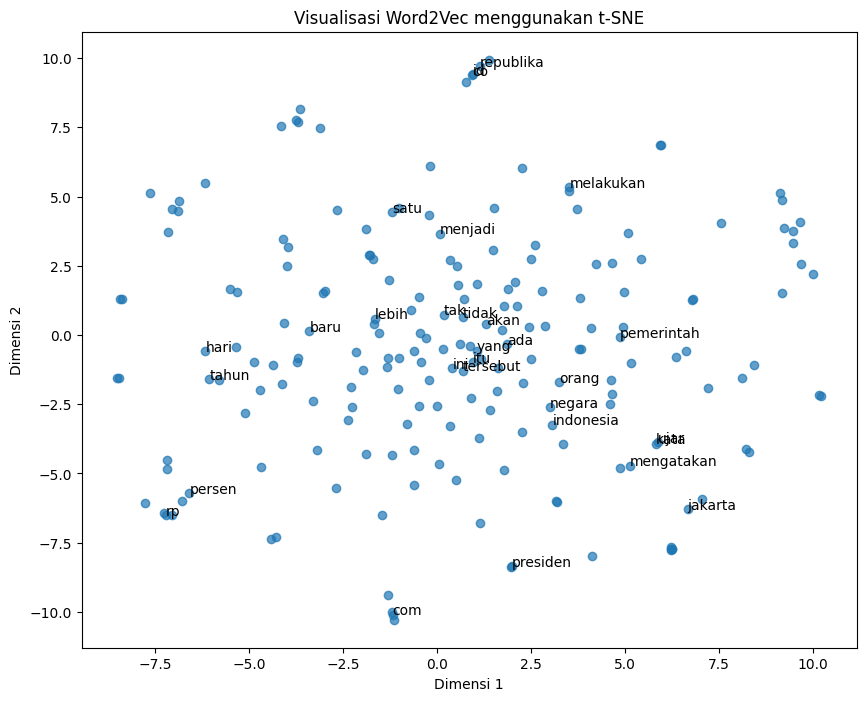

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(vectors_2d[:,0], vectors_2d[:,1], alpha=0.7)

for i, word in enumerate(words[:30]):  # tampilkan label 30 kata saja
    plt.annotate(word, (vectors_2d[i,0], vectors_2d[i,1]))

plt.title("Visualisasi Word2Vec menggunakan t-SNE")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.show()


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/SKRIPSI/word2vec_skipgram.model"
w2v_model.save(MODEL_PATH)

print("Model Word2Vec disimpan:", MODEL_PATH)


Model Word2Vec disimpan: /content/drive/MyDrive/SKRIPSI/word2vec_skipgram.model


In [ ]:
print("Ringkasan Word2Vec:")
print("• Arsitektur      : Skip-Gram")
print("• Dimensi vektor  :", EMBEDDING_DIM)
print("• Context window :", 5)
print("• Vocabulary size:", len(w2v_model.wv))


Ringkasan Word2Vec:
• Arsitektur      : Skip-Gram
• Dimensi vektor  : 100
• Context window : 5
• Vocabulary size: 71000
